In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("../Data/heart.csv")

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [4]:
print(df.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [5]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
print((df['Cholesterol'] == 0).sum())
print((df['RestingBP'] == 0).sum())

172
1


In [8]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

In [9]:
print(df['Cholesterol'].median())
print(df['RestingBP'].median())

223.0
130.0


In [10]:
print(df['Cholesterol'].min())
print(df['RestingBP'].min())

85
80


FileNotFoundError: [Errno 2] No such file or directory: '../images/histplot.png'

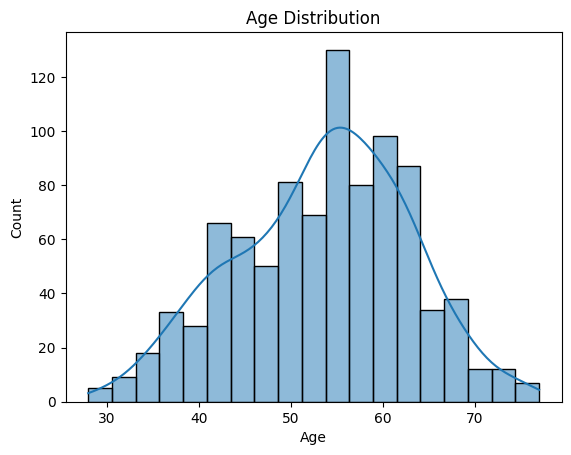

In [11]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.savefig("../images/histplot.png")
plt.show()

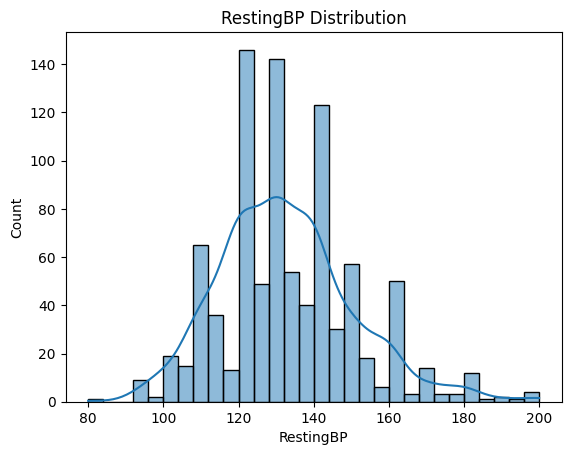

In [12]:
sns.histplot(df['RestingBP'], kde=True)
plt.title("RestingBP Distribution")
plt.show()

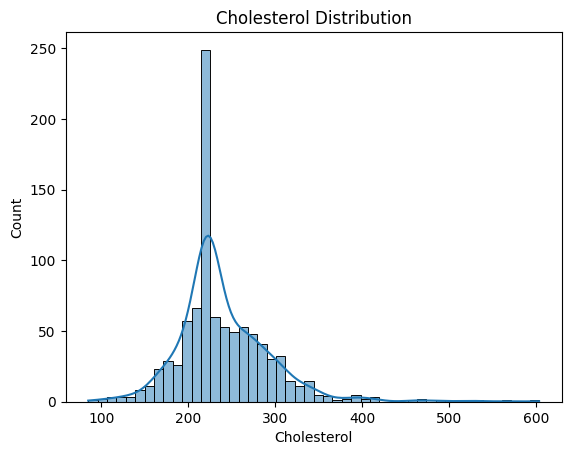

In [13]:
sns.histplot(df['Cholesterol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

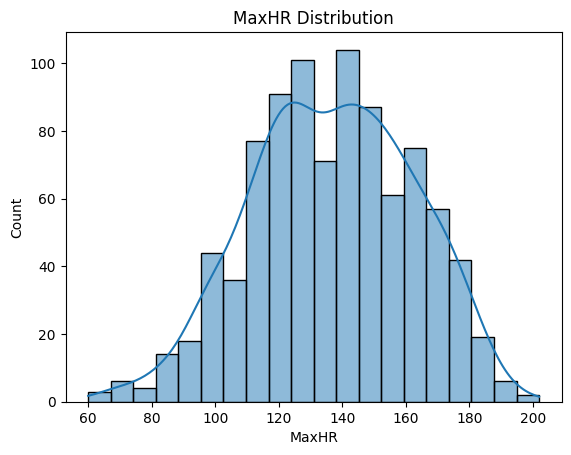

In [14]:
sns.histplot(df['MaxHR'], kde=True)
plt.title("MaxHR Distribution")
plt.show()

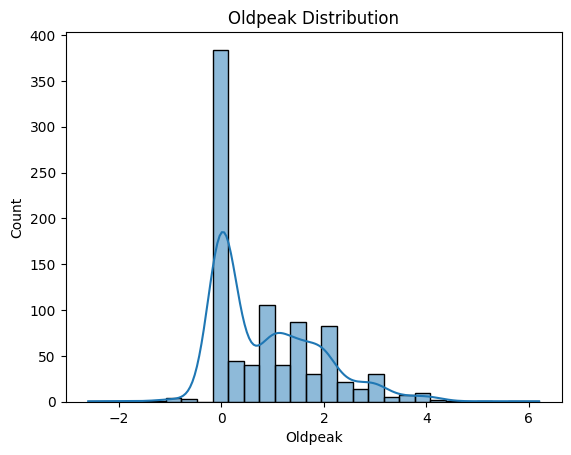

In [15]:
sns.histplot(df['Oldpeak'], kde=True)
plt.title("Oldpeak Distribution")
plt.show()

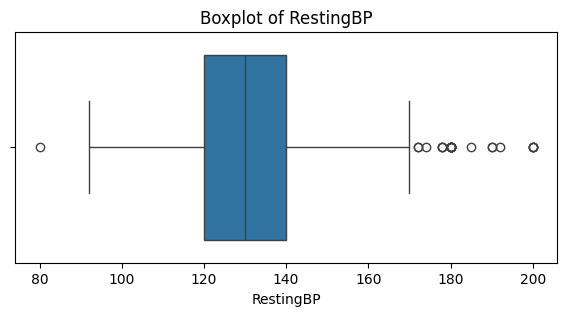

In [16]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df['RestingBP'])
plt.title("Boxplot of RestingBP")
plt.show()

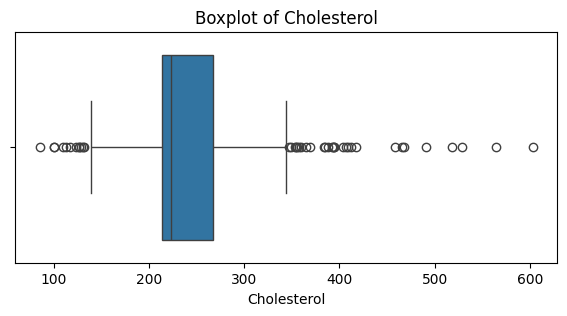

In [17]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df['Cholesterol'])
plt.title("Boxplot of Cholesterol")
plt.show()

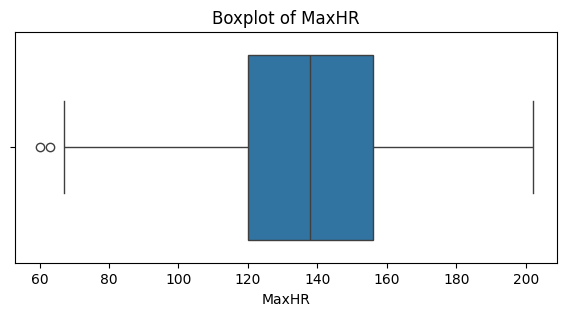

In [18]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df['MaxHR'])
plt.title("Boxplot of MaxHR")
plt.show()

In [19]:
features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

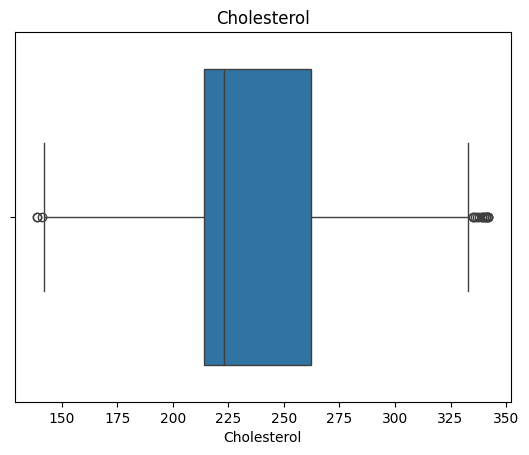

In [20]:
sns.boxplot(x=df['Cholesterol'])
plt.title('Cholesterol')
plt.show()

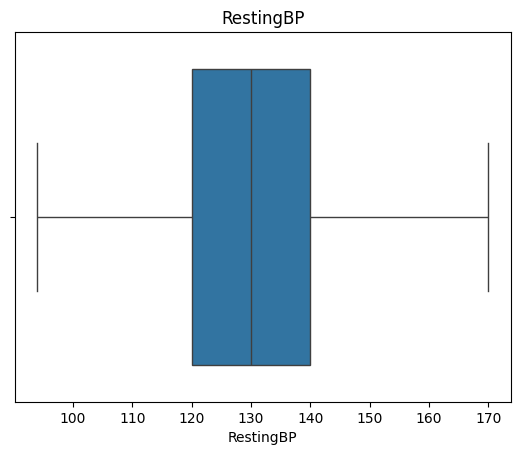

In [21]:
plt.Figure(figsize=(7,3))
sns.boxplot(x=df['RestingBP'])
plt.title("RestingBP")
plt.show()


In [22]:
corr = df[['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']].corr()
corr_percentage = (corr * 100).round(2)
print(corr_percentage)

                Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak
Age          100.00      27.25         4.95      19.24  -40.27    25.89
RestingBP     27.25     100.00         4.63       5.02  -10.40    18.18
Cholesterol    4.95       4.63       100.00      -1.38    4.17     6.77
FastingBS     19.24       5.02        -1.38     100.00  -14.65     8.95
MaxHR        -40.27     -10.40         4.17     -14.65  100.00   -17.52
Oldpeak       25.89      18.18         6.77       8.95  -17.52   100.00


In [23]:
corr_hd = df[['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']].corr()['HeartDisease']
corr_hd_percentage = (corr_hd * 100).round(2)
print(corr_hd_percentage)

Age              29.15
RestingBP        10.95
Cholesterol       5.51
FastingBS        28.24
MaxHR           -40.61
Oldpeak          41.07
HeartDisease    100.00
Name: HeartDisease, dtype: float64


<Figure size 800x600 with 0 Axes>

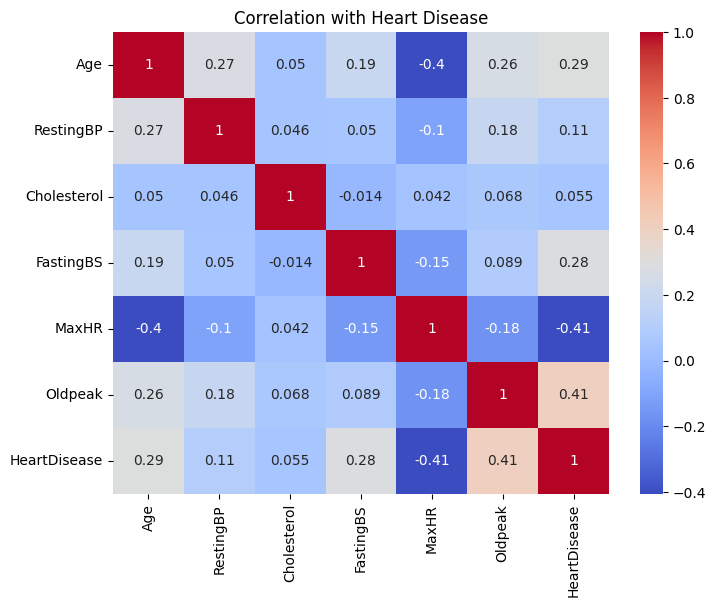

In [ ]:
plt.figure(figsize=(8,6))
plt.figure(figsize=(8,6))
corr = df[['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Heart Disease")
plt.savefig(../)
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['HeartDisease']),df['HeartDisease'],
                                                test_size=0.2)

In [26]:
print(X_train.shape)

(668, 11)


In [27]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer

In [28]:
transformer = ColumnTransformer(transformers=[('ohe',OneHotEncoder(drop='first'),['ChestPainType','RestingECG','ST_Slope']),('oe',OrdinalEncoder(categories=[['F','M'],['N','Y']]), ['Sex','ExerciseAngina']),('scaler',StandardScaler(),['RestingBP','Cholesterol','MaxHR'])],remainder='passthrough')

In [29]:
X_train =transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [30]:
column_names = transformer.get_feature_names_out() 
X_train = pd.DataFrame(X_train, columns=column_names) 
X_test = pd.DataFrame(X_test, columns=column_names) 

In [31]:
print(X_train.head())
print(X_test.head())

   ohe__ChestPainType_ATA  ohe__ChestPainType_NAP  ohe__ChestPainType_TA  \
0                     0.0                     0.0                    0.0   
1                     1.0                     0.0                    0.0   
2                     0.0                     1.0                    0.0   
3                     0.0                     0.0                    0.0   
4                     1.0                     0.0                    0.0   

   ohe__RestingECG_Normal  ohe__RestingECG_ST  ohe__ST_Slope_Flat  \
0                     0.0                 1.0                 0.0   
1                     1.0                 0.0                 0.0   
2                     1.0                 0.0                 0.0   
3                     0.0                 0.0                 1.0   
4                     1.0                 0.0                 0.0   

   ohe__ST_Slope_Up  oe__Sex  oe__ExerciseAngina  scaler__RestingBP  \
0               1.0      1.0                 1.0         

In [32]:
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [33]:
models = [LogisticRegression, SVC, DecisionTreeClassifier, RandomForestClassifier]
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

In [34]:
for model in models:
    classifier = model().fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
classification_metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Decision Tree", "Random Forest"],
    "Accuracy": accuracy_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores
})

In [36]:
classification_metrics_df.set_index('Model', inplace=True)
print(classification_metrics_df)
print(f1_scores)
print(accuracy_scores)

                     Accuracy  Precision    Recall  F1 Score
Model                                                       
Logistic Regression  0.809524   0.793103  0.831325  0.811765
SVM                  0.636905   0.593220  0.843373  0.696517
Decision Tree        0.773810   0.758621  0.795181  0.776471
Random Forest        0.797619   0.775281  0.831325  0.802326
[0.8117647058823529, 0.6965174129353234, 0.7764705882352941, 0.8023255813953488]
[0.8095238095238095, 0.6369047619047619, 0.7738095238095238, 0.7976190476190477]
